*IMPORT LIBARY*

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import PIL
import tensorflow as tf
from tensorflow.keras import layers 
from tensorflow.keras.models import Sequential
import tensorflow_datasets as tsds  #get the dataset from the tensorflow
from tensorflow.keras.layers import Dense,Dropout,Conv2D,MaxPooling2D,Flatten,MaxPooling2D

*TRAIN THE DATASET*

In [2]:
ds_train, ds_info = tsds.load('tf_flowers',split='train',with_info=True,as_supervised=True)

#ds_train → Used for training the model
#ds_info → Used for understanding the datase
#tsds.load() is a function used to download and load datasets that are already prepared by TensorFlow.
#tf_flower -->this is flower dataset
#split='train'-->Give me only the training portion of the dataset
#with_info=True--->this is give the information about the the data
#as_supervised=True--->This is very important for training models.It makes the dataset return data in this format:

*EXAMPLE PICS FROM DATASET*

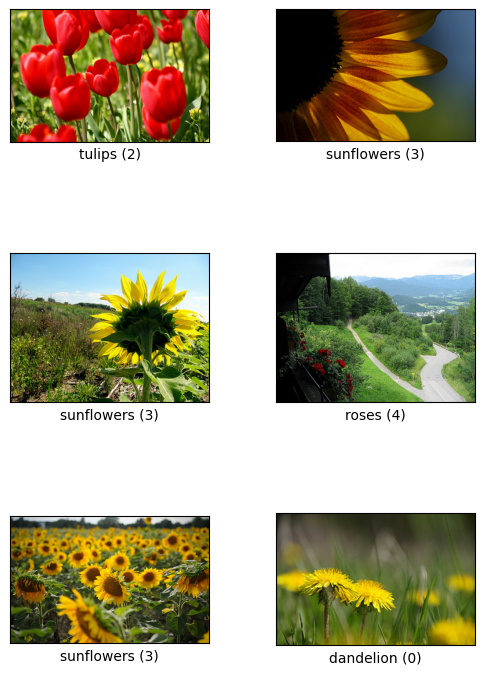

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, None, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>


In [3]:
fig=tsds.show_examples(ds_train,ds_info,rows=3,cols=2)
print(ds_train)
#It displays sample images from the dataset with their labels.

*NORMALIZATION*

In [4]:
IMG_HEIGHT = 180
IMG_WIDTH = 180
BATCH_SIZE = 32

def preprocess_image(image,label):
    image = tf.image.resize(image,(IMG_HEIGHT ,IMG_WIDTH))
    image = tf.cast(image,tf.float32)/255.0       #CONVERT THE PIXAL SIZE INT to FLOAT ,then NORMALIZE
    return image,label

#apply preprocessing in the dataset
ds_processed = ds_train.map(preprocess_image)  #It applies the preprocessing function to every image in the dataset and creates a new processed dataset.


*CALCULATION*

In [5]:
#calculate dataset size for splitting
DATASET_SIZE = ds_info.splits['train'].num_examples
train_size = int(0.8 * DATASET_SIZE)
val_size = DATASET_SIZE - train_size
print(DATASET_SIZE)
print(train_size)
print(val_size)

3670
2936
734


*IMPROVE TRAINING SPEED*

In [6]:
AUTOTUNE = tf.data.AUTOTUNE #TensorFlow automatically optimize data loading , Improves training speed
ds_shuffled= ds_processed.shuffle(buffer_size=DATASET_SIZE,seed=123) # Randomly rearranges the dataset samples.buffer_size=DATASET_SIZE → full dataset shuffling,seed=123 → same shuffle order every run (reproducibility)

train_ds =ds_shuffled.take(train_size).batch(BATCH_SIZE).cache().prefetch(buffer_size=AUTOTUNE) # PREFETCH--->Prepares next batch while the model trains,PREVENT DATA LOADING DELAY
val_ds =ds_shuffled.skip(train_size).batch(BATCH_SIZE).cache().prefetch(buffer_size=AUTOTUNE)  #CACHE--->Stores processed data in memorY ,Avoids reprocessing images every epoch

print(f'Number of training batches:{len(train_ds)}')
print(f'Number of validation batches:{len(val_ds)}')

Number of training batches:92
Number of validation batches:23


*NAME FOR IMAGE*

In [7]:
flower_class_names = ds_info.features['label'].names
print(flower_class_names)
#It extracts and prints the human-readable class names of the labels in the dataset.

['dandelion', 'daisy', 'tulips', 'sunflowers', 'roses']


*LENGHT FOR FLOWERS NAME*

In [8]:
len(flower_class_names)

5

*CREAT MODEL*

In [9]:
model=Sequential([
    layers.Conv2D(16,3, padding='same', activation='relu'),
    layers.MaxPool2D(),
    layers.Conv2D(32,3, padding='same', activation='relu'),
    layers.MaxPool2D(),
    layers.Conv2D(64,3, padding='same', activation='relu'),
    layers.MaxPool2D(),
    layers.Flatten(),
    layers.Dense(128,activation='relu'),
    layers.Dense(len(flower_class_names))
    ])

*COMPILE*

In [10]:
model.compile(optimizer='adam',loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),metrics=['accuracy'])

*EPOCHS*

In [11]:
history=model.fit(train_ds,epochs=10,validation_data=val_ds)

Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 23s 212ms/step - accuracy: 0.4240 - loss: 1.3513 - val_accuracy: 0.6226 - val_loss: 0.9900
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 18s 194ms/step - accuracy: 0.6090 - loss: 0.9885 - val_accuracy: 0.6989 - val_loss: 0.8093
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 18s 190ms/step - accuracy: 0.7112 - loss: 0.7850 - val_accuracy: 0.7657 - val_loss: 0.6405
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 18s 196ms/step - accuracy: 0.7933 - loss: 0.5810 - val_accuracy: 0.7861 - val_loss: 0.5966
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 18s 193ms/step - accuracy: 0.8696 - loss: 0.3829 - val_accuracy: 0.8556 - val_loss: 0.4232
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 18s 191ms/step - accuracy: 0.8839 - loss: 0.3187 - val_accuracy: 0.8256 - val_loss: 0.5381
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 19s 201ms/step - accuracy: 0.9142 - loss: 0.2601 - val_accuracy: 0.8719 - val_loss: 0.4095
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 18s 194ms/step - accuracy: 0.9411 - loss: 0.1765 - val_accu

*PLOT 1*

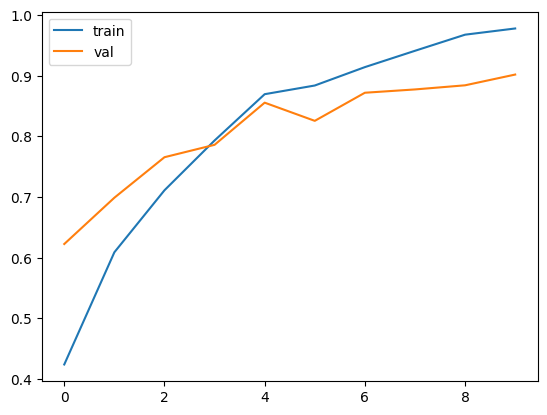

In [12]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'],label='train')
plt.plot(history.history['val_accuracy'],label='val')
plt.legend()
plt.show()

*PLOT 2*

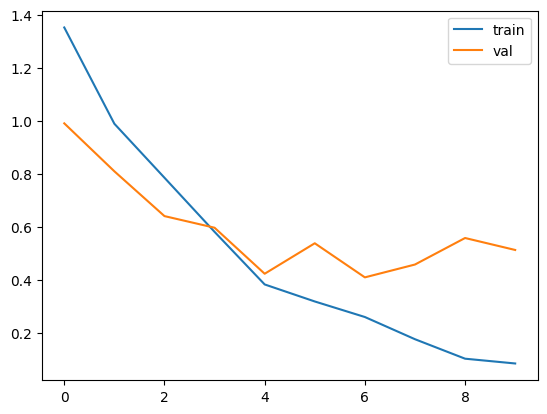

In [13]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'],label='train')
plt.plot(history.history['val_loss'],label='val')
plt.legend()
plt.show()

*MAKE PREDICITION*

In [14]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image
img_height = 180
img_width = 180

class_names = ['dandelion', 'daisy', 'tulips', 'sunflowers', 'roses']

img_path = r"C:\Users\admin\Desktop\CNN\tulip flower pic.jpg"  # Change image path
img = image.load_img(img_path, target_size=(img_height, img_width))
img_array = image.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)  # Add batch dimension

predictions = model.predict(img_array)
score = tf.nn.softmax(predictions[0])

print("Predicted emotion:", class_names[np.argmax(score)])
print("Confidence: {:.2f}%".format(100 * np.max(score)))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
Predicted emotion: daisy
Confidence: 100.00%


*DISPLAY THE IMAGE*

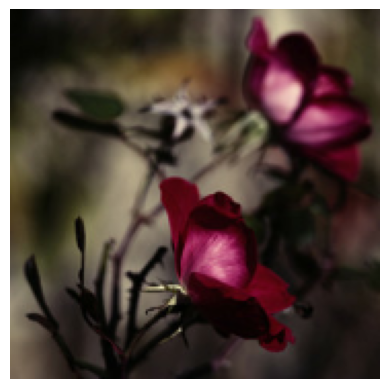

In [15]:
plt.axis('off')
#get one batch from the training dataset
for images,labels in train_ds.take(1):
    #display the  image in the batch
    plt.imshow(images[18])

*DATA AGUMENTATION*

In [20]:
data_agumentation = Sequential([
    layers.RandomFlip("horizontal",input_shape=(IMG_HEIGHT,IMG_WIDTH,3)),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

c:\Users\admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [24]:
model=Sequential([
    data_agumentation,
    layers.Conv2D(16,3, padding='same', activation='relu'),
    layers.MaxPool2D(),
    layers.Conv2D(32,3, padding='same', activation='relu'),
    layers.MaxPool2D(),
    layers.Conv2D(64,3, padding='same', activation='relu'),
    layers.MaxPool2D(),
    layers.Dropout(0.2),
    layers.Flatten(),
    layers.Dense(128,activation='relu'),
    layers.Dense(len(flower_class_names))
    ])

In [25]:
model.compile(optimizer='adam',loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),metrics=['accuracy'])

In [26]:
history=model.fit(train_ds,epochs=10,validation_data=val_ds)

Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 24s 235ms/step - accuracy: 0.4496 - loss: 1.3414 - val_accuracy: 0.5940 - val_loss: 1.0363
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 22s 242ms/step - accuracy: 0.5995 - loss: 1.0262 - val_accuracy: 0.6594 - val_loss: 0.8828
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 22s 242ms/step - accuracy: 0.6304 - loss: 0.9424 - val_accuracy: 0.6689 - val_loss: 0.8415
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 22s 239ms/step - accuracy: 0.6669 - loss: 0.8665 - val_accuracy: 0.6894 - val_loss: 0.8228
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 22s 241ms/step - accuracy: 0.6887 - loss: 0.8232 - val_accuracy: 0.7057 - val_loss: 0.7812
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 22s 242ms/step - accuracy: 0.7040 - loss: 0.7655 - val_accuracy: 0.7193 - val_loss: 0.7632
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 22s 238ms/step - accuracy: 0.7125 - loss: 0.7417 - val_accuracy: 0.7371 - val_loss: 0.7081
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 22s 241ms/step - accuracy: 0.7360 - loss: 0.6974 - val_accu

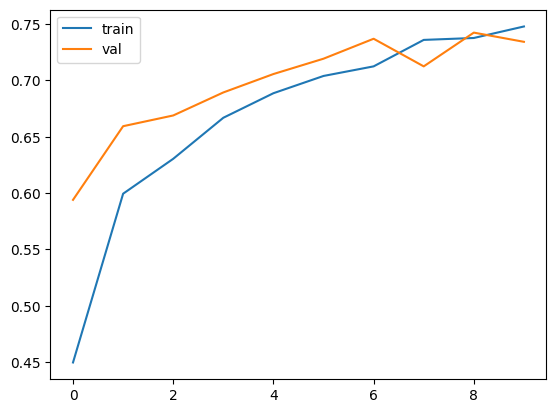

In [27]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'],label='train')
plt.plot(history.history['val_accuracy'],label='val')
plt.legend()
plt.show()

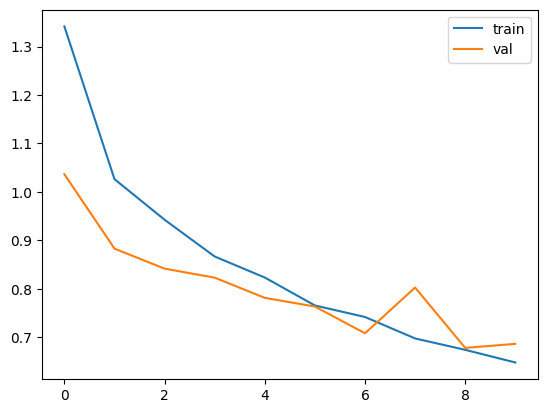

In [28]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'],label='train')
plt.plot(history.history['val_loss'],label='val')
plt.legend()
plt.show()